import pandas as pd
import numpy as np

In [3]:
path='/content/drive/MyDrive/Colab Notebooks/ML practical/cleaned_project_data.csv'
data=pd.read_csv(path)

In [4]:
data.shape

(2455616, 23)

In [5]:
data.size

56479168

In [6]:
data.columns

Index(['Unnamed: 0', 'Severity', 'Distance(mi)', 'Description',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Weather_Condition', 'Crossing', 'Give_Way', 'Junction', 'Railway',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='object')

# Remove Outliers

Distance(mi), Tempreture(F), Wind_Chill(F), Humidity(%), Visibility(mi), Wind_Speed(mph) shows outliers presents in EDA

In [7]:
data.drop(['Unnamed: 0'],axis=1,inplace=True)

In [8]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 8.2 MB/s eta 0:00:00


In [9]:
from feature_engine.outliers import Winsorizer

In [10]:
winsor = Winsorizer(capping_method='iqr', tail='both', fold=1.5)

<Axes: ylabel='Distance(mi)'>

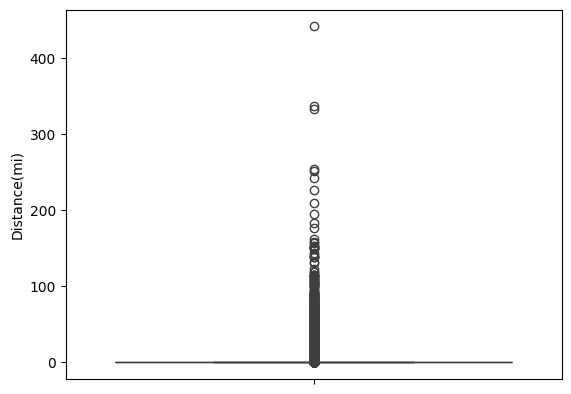

In [11]:
from seaborn import boxplot
boxplot(data['Distance(mi)'])

<Axes: >

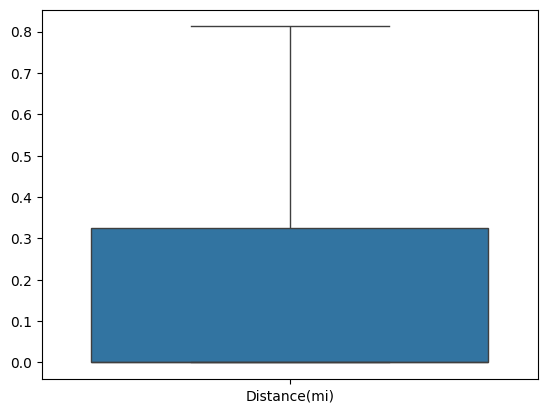

In [12]:
boxplot(winsor.fit_transform(data[['Distance(mi)']]))

From above simulation we can clearly see that Winsorizer are capable to remove Outliers

From above simulation we can clearly see that Winsorizer are capable to remove Outliers

In [13]:
num_cols = list(data.select_dtypes(include='number').columns)[2:]
print(num_cols)

['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']


In [14]:
for col in num_cols:
    data[col.lower()] = winsor.fit_transform(data[[col]])

<Axes: ylabel='wind_chill(f)'>

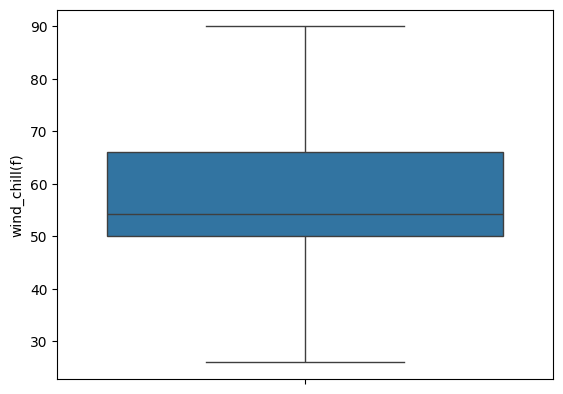

In [15]:
boxplot(data['wind_chill(f)'])

Now we have succesfully remove outliers from the dataframe

# Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder
import re

In [17]:
# data['Weather_Timestamp']=LabelEncoder().fit_transform(data['Weather_Timestamp'])
data['Wind_Direction']=LabelEncoder().fit_transform(data['Wind_Direction'])
data['Weather_Condition']=LabelEncoder().fit_transform(data['Weather_Condition'])
data['Crossing']=LabelEncoder().fit_transform(data['Crossing'])
data['Junction']=LabelEncoder().fit_transform(data['Junction'])
data['Railway']=LabelEncoder().fit_transform(data['Railway'])
data['Give_Way']=LabelEncoder().fit_transform(data['Give_Way'])
data['Stop']=LabelEncoder().fit_transform(data['Stop'])
data['Traffic_Calming']=LabelEncoder().fit_transform(data['Traffic_Calming'])
data['Traffic_Signal']=LabelEncoder().fit_transform(data['Traffic_Signal'])
data['Sunrise_Sunset']=LabelEncoder().fit_transform(data['Sunrise_Sunset'])
data['Civil_Twilight']=LabelEncoder().fit_transform(data['Civil_Twilight'])
data['Nautical_Twilight']=LabelEncoder().fit_transform(data['Nautical_Twilight'])
data['Astronomical_Twilight']=LabelEncoder().fit_transform(data['Astronomical_Twilight'])

# Extract Hour and Minute from Weather_Timestamp

In [18]:
data['Weather_Timestamp'] = pd.to_datetime(data['Weather_Timestamp'])

# Extract hour and minute into new columns
data['Hour'] = data['Weather_Timestamp'].dt.hour
data['Minute'] = data['Weather_Timestamp'].dt.minute

# Display the new columns
display(data[['Weather_Timestamp', 'Hour', 'Minute']].head())

,Weather_Timestamp,Hour,Minute
0,2022-04-21 18:19:00,18,19
1,2021-10-11 18:43:00,18,43
2,2021-09-20 05:56:00,5,56
3,2021-01-30 18:53:00,18,53
4,2020-10-12 08:53:00,8,53


In [19]:
data.drop(['Weather_Timestamp'],axis=1,inplace=True)

In [20]:
data.head()

,Severity,Distance(mi),Description,Temperature(F),Wind_Chill(F),Humidity(%),Visibility(mi),Wind_Direction,Wind_Speed(mph),Weather_Condition,...,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,temperature(f),wind_chill(f),humidity(%),visibility(mi),wind_speed(mph),Hour,Minute
0,3,0.0,Two lanes blocked due to crash on I-15 Northbo...,74.0,74.0,13.0,5.0,16,14.0,0,...,0,0,0,74.0,74.0,13.0,5.0,14.0,18,19
1,3,0.0,#1 lane blocked due to accident on I-405 North...,65.0,65.0,18.0,4.0,6,20.0,0,...,0,0,0,65.0,65.0,18.0,4.0,20.0,18,43
2,3,0.0,Left lane blocked due to accident on I-15 Sout...,50.0,50.0,59.0,10.0,9,15.0,0,...,1,1,0,50.0,50.0,59.0,10.0,15.0,5,56
3,3,0.0,Two lanes blocked due to accident on US-75 Cen...,70.0,70.0,17.0,4.0,20,9.0,0,...,1,1,0,70.0,70.0,17.0,4.0,9.0,18,53
4,3,0.0,Accident on Stemmons Fwy Svrd Northbound at In...,72.0,72.0,41.0,6.0,6,12.0,0,...,0,0,0,72.0,72.0,41.0,6.0,12.0,8,53


In [21]:
data.columns

Index(['Severity', 'Distance(mi)', 'Description', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Weather_Condition', 'Crossing', 'Give_Way',
       'Junction', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'temperature(f)', 'wind_chill(f)',
       'humidity(%)', 'visibility(mi)', 'wind_speed(mph)', 'Hour', 'Minute'],
      dtype='object')

In [23]:
data['Severity'].value_counts()

,count
Severity,
3,1258196
2,947122
4,188724
1,61574


In [24]:
print(f"Original shape: {data.shape}")

Original shape: (2455616, 28)


In [25]:
target_samples = {1: 61574, 2: 70000, 3: 70000, 4: 70000}

data_1 = data[data['Severity'] == 1]
data_2 = data[data['Severity'] == 2].sample(n=70000, random_state=42)
data_3 = data[data['Severity'] == 3].sample(n=70000, random_state=42)
data_4 = data[data['Severity'] == 4].sample(n=70000, random_state=42)

balanced_data = pd.concat([data_1, data_2, data_3, data_4], axis=0)
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)


In [26]:
print(balanced_data['Severity'].value_counts())

Severity
4    70000
3    70000
2    70000
1    61574
Name: count, dtype: int64


In [27]:
balanced_data.shape

(271574, 28)

In [28]:
balanced_data.size

7604072

In [30]:
balanced_data.columns

Index(['Severity', 'Distance(mi)', 'Description', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Weather_Condition', 'Crossing', 'Give_Way',
       'Junction', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'temperature(f)', 'wind_chill(f)',
       'humidity(%)', 'visibility(mi)', 'wind_speed(mph)', 'Hour', 'Minute'],
      dtype='object')

In [54]:
balanced_data.shape

(271574, 28)

In [55]:
balanced_data.size

7604072

In [31]:
!pip install sentence-transformers

In [32]:
from sentence_transformers import SentenceTransformer

In [33]:
print("Loading sentence-transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading sentence-transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [34]:
import torch
if torch.cuda.is_available():
    print("✅ GPU is available and PyTorch can see it.")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("❌ ERROR: PyTorch CANNOT see the GPU.")
    print("Make sure you are on a 'T4 GPU' runtime and have restarted.")

✅ GPU is available and PyTorch can see it.
Device Name: Tesla T4


In [35]:
print("\nCreating 384-dimensional embeddings...")
descriptions_list = balanced_data['Description'].tolist()
embeddings_384d = model.encode(descriptions_list, show_progress_bar=False)
print(f"Original embeddings shape: {embeddings_384d.shape}")


Creating 384-dimensional embeddings...
Original embeddings shape: (271574, 384)


In [36]:
df_embeddings = pd.DataFrame(embeddings_384d)
print(df_embeddings.head())

        0         1         2         3         4         5         6    \
0  0.027196 -0.024356  0.066474  0.014036 -0.011253  0.038582 -0.032406   
1 -0.054620 -0.013700 -0.011458  0.011087  0.041231  0.017372  0.044550   
2  0.019718  0.022145  0.006064  0.048739 -0.003075  0.059048 -0.039129   
3  0.009937  0.122721  0.058932 -0.023097  0.020021  0.043733 -0.038973   
4 -0.027401  0.034188  0.065243 -0.004139  0.016065  0.058207 -0.050533   

        7         8         9    ...       374       375       376       377  \
0 -0.004928 -0.039671  0.036384  ... -0.018413  0.046055 -0.005465 -0.029651   
1  0.020588 -0.053210 -0.000019  ...  0.035645  0.013841  0.052806 -0.049608   
2  0.022121 -0.089447  0.033969  ... -0.012830  0.008827 -0.036448 -0.094916   
3  0.105606 -0.026687 -0.001816  ... -0.067532  0.022489 -0.005757 -0.036306   
4  0.036756 -0.003064  0.072485  ... -0.048888  0.010744  0.005196 -0.061816   

        378       379       380       381       382       383  
0 -0

In [37]:
from sklearn.decomposition import PCA

In [39]:
print("Applying PCA...")
n_components = 100
pca = PCA(n_components=n_components)
embeddings_100d = pca.fit_transform(embeddings_384d)
print(f"PCA complete. New shape: {embeddings_100d.shape}")

Applying PCA...
PCA complete. New shape: (271574, 100)


* CREATE A DATAFRAME FOR THE PCA RESULTS
* It's helpful to give them names, like
'pca_0', 'pca_1',

In [40]:
pca_columns = [f'pca_{i}' for i in range(n_components)]
df_pca_embeddings = pd.DataFrame(embeddings_100d, columns=pca_columns)

In [41]:
df_pca_embeddings.head()

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,...,pca_90,pca_91,pca_92,pca_93,pca_94,pca_95,pca_96,pca_97,pca_98,pca_99
0,-0.006191,0.445149,-0.002447,0.087130,-0.062631,-0.028626,0.080612,-0.121012,0.163994,0.011345,...,-0.056127,0.041502,0.013808,-0.023963,-0.055840,0.037744,-0.018599,-0.011841,-0.010552,-0.040150
1,0.472828,-0.020121,0.006489,-0.000839,-0.092227,0.152765,-0.039443,-0.113499,-0.036104,0.041103,...,0.027190,-0.012125,-0.002564,-0.007074,-0.012287,-0.000748,-0.008884,0.029169,-0.007910,0.006209
2,-0.019358,0.269212,-0.237431,0.018596,0.181773,-0.085235,-0.163806,0.001073,0.047620,-0.231670,...,-0.015665,0.047770,-0.015096,-0.005548,-0.036345,0.015864,0.035307,0.013516,0.000067,0.031614
3,-0.280717,-0.187971,-0.005635,0.274400,-0.031524,0.026236,-0.013609,0.191160,0.039008,0.029620,...,0.017631,-0.045862,-0.000497,0.015063,0.021053,-0.003587,0.020831,0.006535,0.000665,0.002502
4,-0.358979,-0.145995,-0.018802,0.228193,0.005492,0.071785,0.139136,-0.000096,-0.168875,0.002826,...,-0.032998,-0.042499,-0.013562,-0.056300,-0.036940,0.036233,-0.078416,-0.025924,-0.005605,0.055101


In [42]:
final_features=balanced_data.copy()

In [43]:
final_features=final_features.reset_index(drop=True)
df_pca_embeddings=df_pca_embeddings.reset_index(drop=True)

In [44]:
final_features = pd.concat([final_features, df_pca_embeddings], axis=1)

In [45]:
final_features.columns

Index(['Severity', 'Distance(mi)', 'Description', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Weather_Condition',
       ...
       'pca_90', 'pca_91', 'pca_92', 'pca_93', 'pca_94', 'pca_95', 'pca_96',
       'pca_97', 'pca_98', 'pca_99'],
      dtype='object', length=128)

In [46]:
final_features.shape

(271574, 128)

In [47]:
final_features.size

34761472

In [53]:
final_features.to_csv("final_processed_data.csv")